<center><img src="redpopcorn.jpg"></center>

**Netflix**! What started in 1997 as a DVD rental service has since exploded into one of the largest entertainment and media companies.

Given the large number of movies and series available on the platform, it is a perfect opportunity to flex your exploratory data analysis skills and dive into the entertainment industry.

You work for a production company that specializes in nostalgic styles. You want to do some research on movies released in the 1990's. You'll delve into Netflix data and perform exploratory data analysis to better understand this awesome movie decade!

You have been supplied with the dataset `netflix_data.csv`, along with the following table detailing the column names and descriptions. Feel free to experiment further after submitting!

## The data
### **netflix_data.csv**
| Column | Description |
|--------|-------------|
| `show_id` | The ID of the show |
| `type` | Type of show |
| `title` | Title of the show |
| `director` | Director of the show |
| `cast` | Cast of the show |
| `country` | Country of origin |
| `date_added` | Date added to Netflix |
| `release_year` | Year of Netflix release |
| `duration` | Duration of the show in minutes |
| `description` | Description of the show |
| `genre` | Show genre |

In [39]:
# Importing pandas and matplotlib
import pandas as pd
import matplotlib.pyplot as plt

# Read in the Netflix CSV as a DataFrame
netflix_df = pd.read_csv("netflix_data.csv")
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93,After a devastating earthquake hits Mexico Cit...,Dramas
1,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78,"When an army recruit is found dead, his fellow...",Horror Movies
2,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action
3,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123,A brilliant group of students become card-coun...,Dramas
4,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,"July 1, 2017",2016,1,A genetics professor experiments with a treatm...,International TV


In [40]:
#Overview of the data
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4812 entries, 0 to 4811
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       4812 non-null   object
 1   type          4812 non-null   object
 2   title         4812 non-null   object
 3   director      4812 non-null   object
 4   cast          4812 non-null   object
 5   country       4812 non-null   object
 6   date_added    4812 non-null   object
 7   release_year  4812 non-null   int64 
 8   duration      4812 non-null   int64 
 9   description   4812 non-null   object
 10  genre         4812 non-null   object
dtypes: int64(2), object(9)
memory usage: 413.7+ KB


In [41]:
#the datafame has 11 colums, no null values, and target colums are in the right data fomat
#checking for duplicate values to ensure the data isnt messed
netflix_df.duplicated().sum()

0

In [42]:
#subsetting data to isolate movies released in the 90s
subset = netflix_df["release_year"].between(1990,1999)
netflix_df = netflix_df[subset]
netflix_df["release_year"].value_counts()

1997    26
1998    26
1999    26
1993    16
1995    16
1992    16
1996    15
1990    15
1991    14
1994    14
Name: release_year, dtype: int64

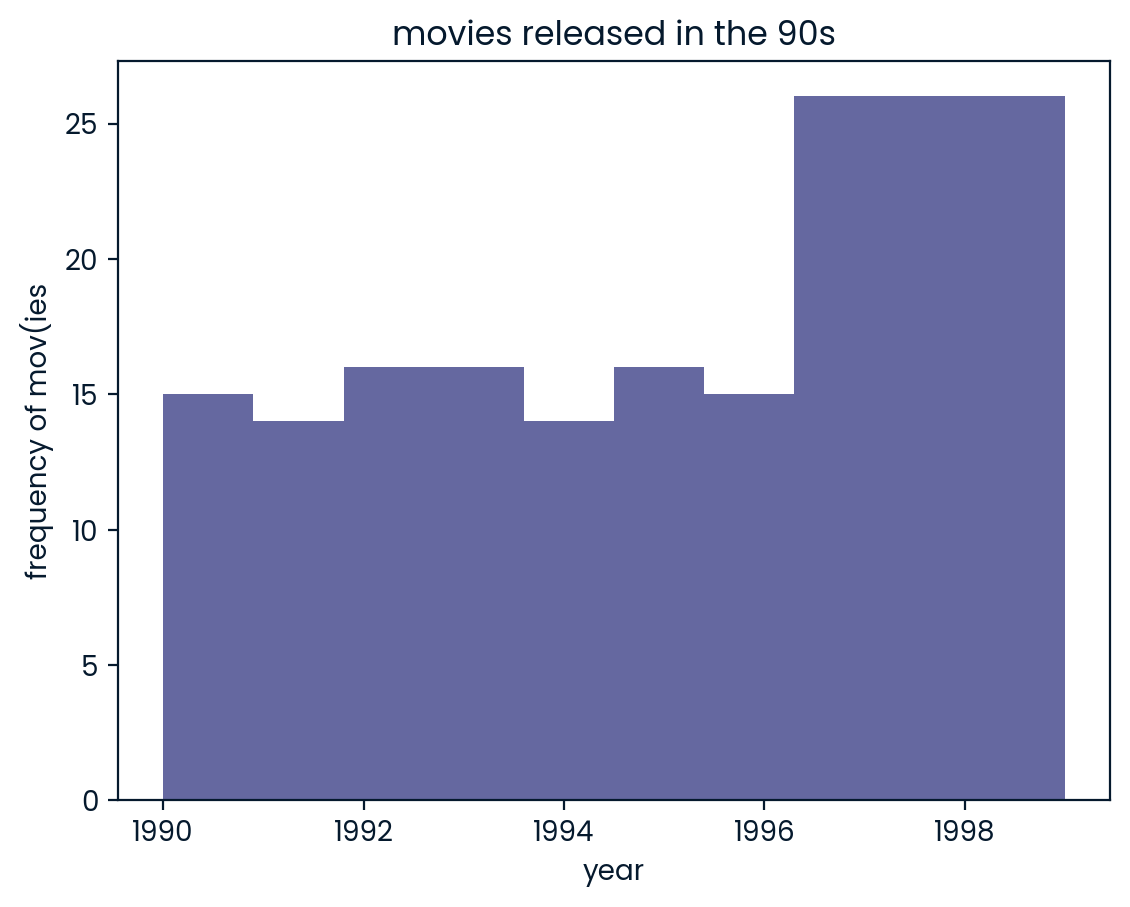

In [43]:
#create histogram to visualize the movies from the 90s
plt.hist(netflix_df["release_year"])
plt.xlabel('year')
plt.ylabel('frequency of mov(ies')
plt.title('movies released in the 90s')
plt.show();

In [44]:
#frequent movie duration in the 1990s? Save an approximate answer as an integer called duration
netflix_df["duration"].value_counts()
#using mode to find the most fequent movies
duration = netflix_df["duration"].mode().sum()
duration
duration.dtype

dtype('int64')

In [45]:
#number of short action movies released in the 1990s and save this integer as short_movie_count 
#Check out the different genres of movies
netflix_df["genre"].value_counts()

Action            48
Dramas            44
Comedies          40
Children          15
Classic Movies    15
Stand-Up           8
Thrillers          5
Horror Movies      4
Documentaries      2
Cult Movies        2
Docuseries         1
Name: genre, dtype: int64

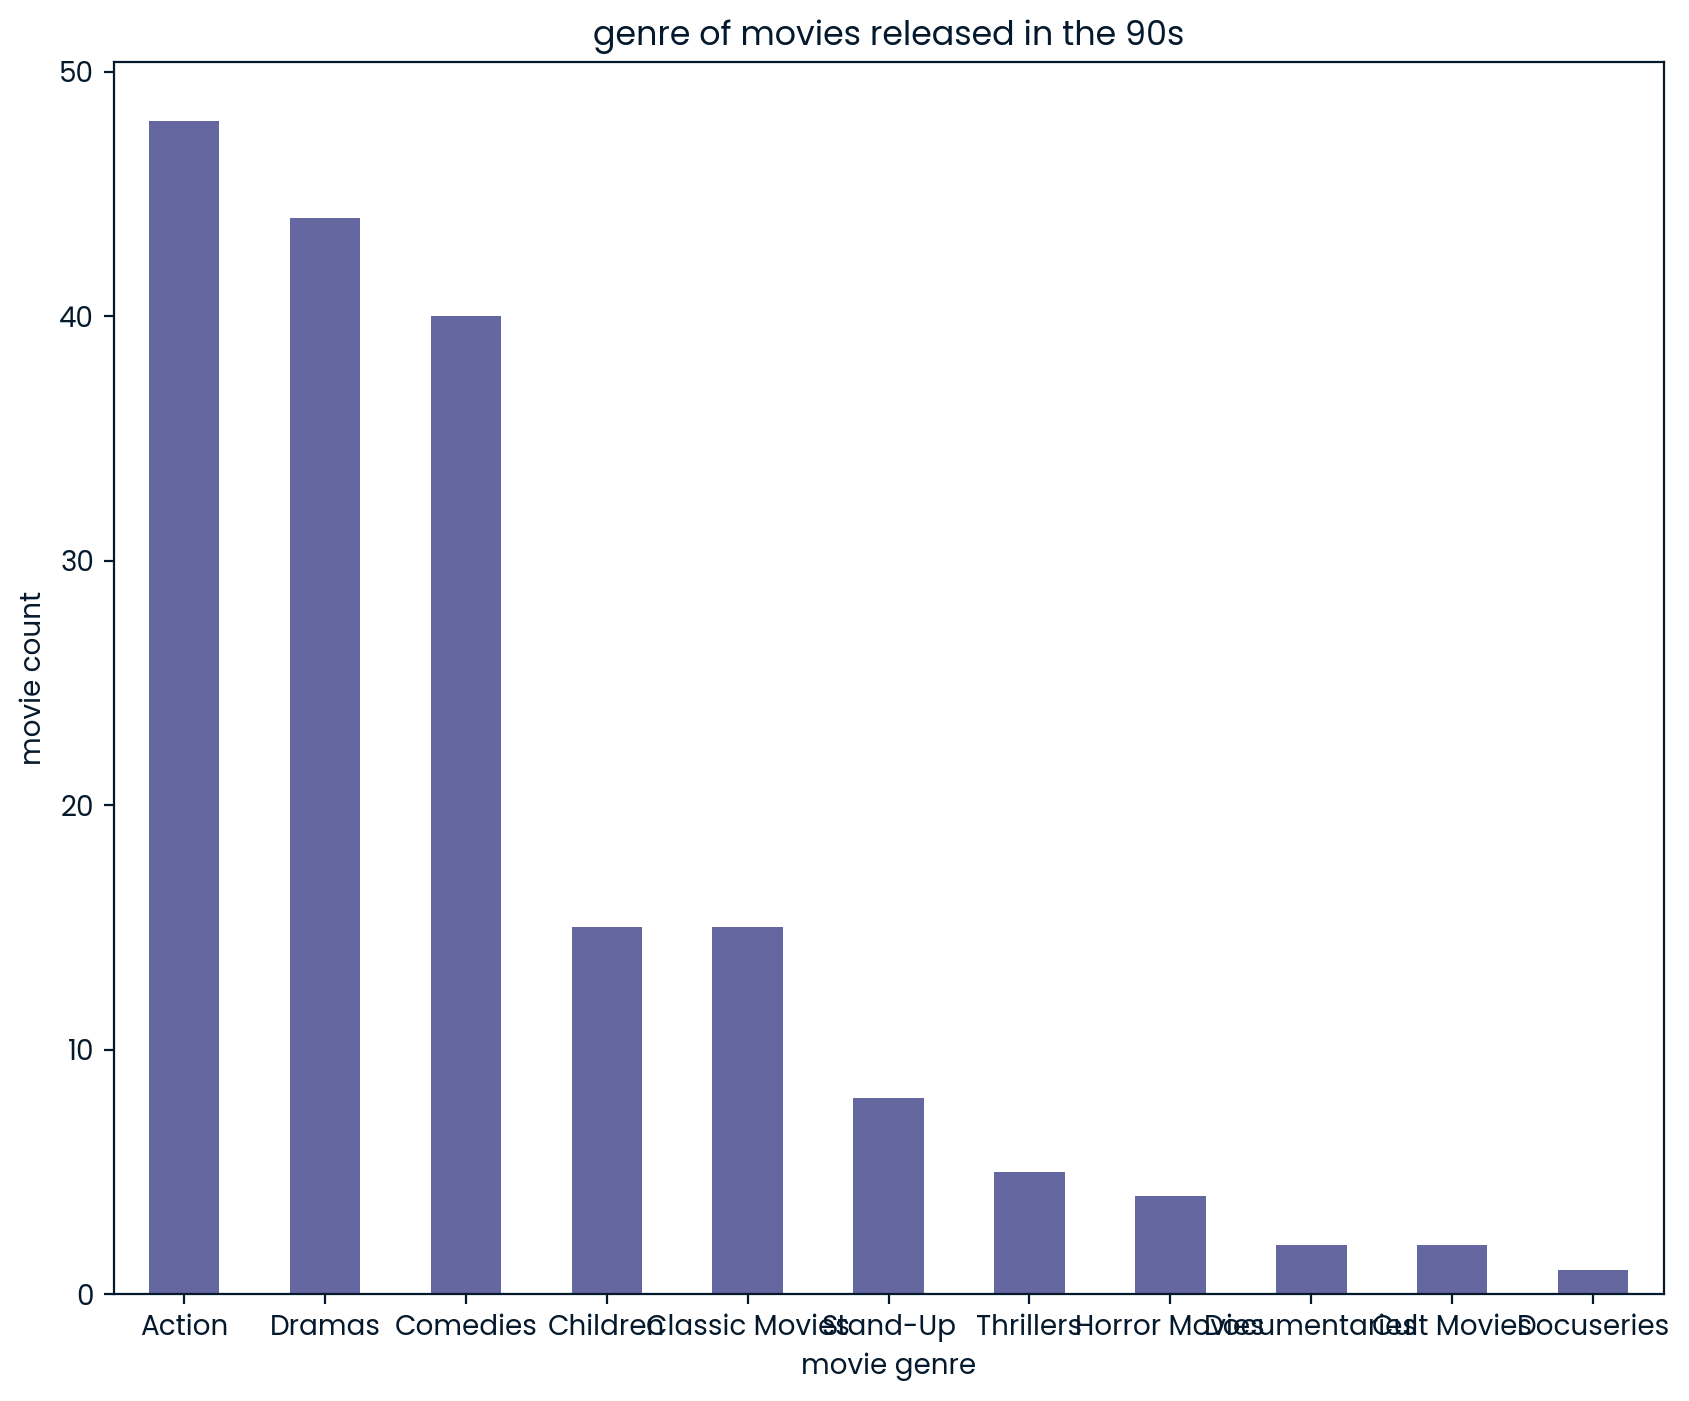

In [46]:
#vizualize the different genres of movies released in the 90s
netflix_df["genre"].value_counts().plot(kind="bar", figsize=(10,8), rot=0)
plt.xlabel('movie genre')
plt.ylabel('movie count')
plt.title('genre of movies released in the 90s');

In [47]:
#Subsetting short action movies with less than 90 minutes
short_action_movie = (netflix_df["genre"]== "Action") & (netflix_df["duration"] < 90)
short_action_movie

6       False
118     False
145     False
167     False
194     False
        ...  
4672    False
4689    False
4718    False
4746    False
4756    False
Length: 184, dtype: bool

In [48]:
#total count of movies with short duration
short_movie_count = short_action_movie.sum()
short_movie_count

7